# Imports

In [1]:
from langchain_core.documents import Document
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_mistralai import ChatMistralAI
from langchain_huggingface import HuggingFaceEmbeddings

from src.pipeline import FAISSRetrieverWrapper, AgenticRAGPipeline, ChatModelWrapper
from src.testing import RAGTester

c:\Users\mibam\Documents\delaware_rag_assignement\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

# Load Groq API Key
with open("groq_api_key.txt", "r") as f:
    os.environ["GROQ_API_KEY"] = f.read().strip()

# Load Mistral API Key
with open("mistral_api_key.txt", "r") as f:
    os.environ["MISTRAL_API_KEY"] = f.read().strip()

# Usage

## Loading corpus into (local) vectorstore

In [13]:
events_dataset = load_dataset("aeriesec/orgforge",data_dir="corpus", split="train")

raw_docs = []
for row in events_dataset:

    content = (
        f"Title: {row.get('title', 'Unknown Title')}\n"
        f"Document Type: {row.get('doc_type', 'Unknown')}\n"
        f"Content: {row.get('body', '')}"
    )

    raw_docs.append(Document(
        page_content=content,
        metadata={
            "doc_id": row.get('doc_id', 'unknown'),
            "actors": ", ".join(row.get('actors', [])),
            "date": str(row.get('date', 'unknown'))
        }
    ))



### Displaying document lengths

This is done to assess the corpus and decide what ``chunk_size`` and ``chunk_overlap`` should be.

--- Document Length Statistics (in characters) ---
count    1403.000000
mean      231.444048
std       145.966117
min        62.000000
50%       188.000000
75%       330.000000
90%       395.800000
95%       436.900000
99%       839.820000
max      1216.000000
dtype: float64


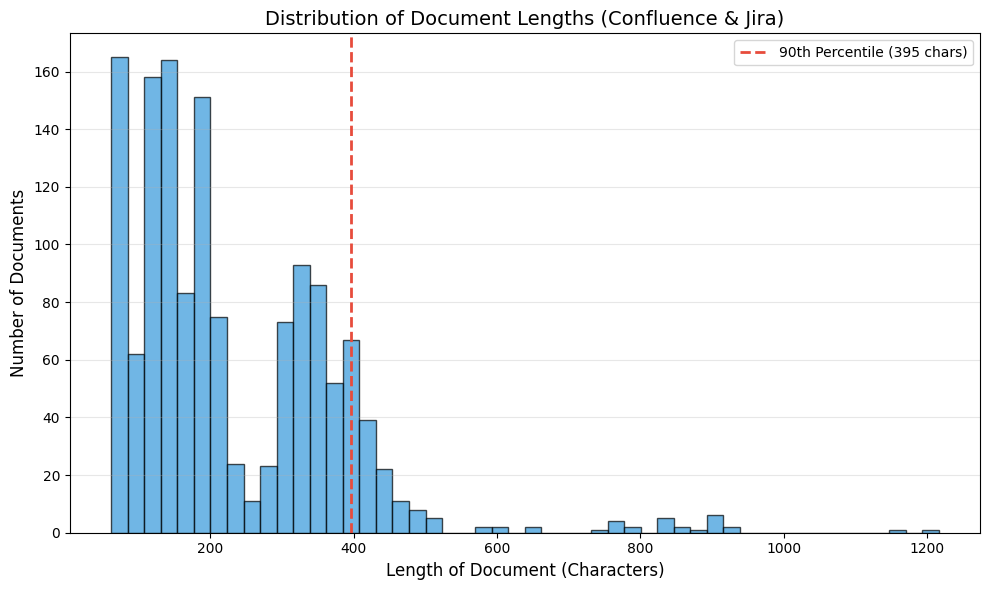

In [14]:
# 1. Extract the lengths of all the formatted documents
doc_lengths = [len(doc.page_content) for doc in raw_docs]

# 2. Convert to a Pandas Series to easily get statistical percentiles
lengths_series = pd.Series(doc_lengths)
print("--- Document Length Statistics (in characters) ---")
print(lengths_series.describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

# 3. Plot the histogram
plt.figure(figsize=(10, 6))
plt.hist(doc_lengths, bins=50, color='#3498db', edgecolor='black', alpha=0.7)

# Add a vertical line for the 90th percentile to help visualize a good cutoff
p90 = np.percentile(doc_lengths, 90)
plt.axvline(p90, color='#e74c3c', linestyle='dashed', linewidth=2, label=f'90th Percentile ({int(p90)} chars)')

plt.title('Distribution of Document Lengths (Confluence & Jira)', fontsize=14)
plt.xlabel('Length of Document (Characters)', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Initialize the text splitter
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,
    chunk_overlap=50,
    separators=["\n\n", "\n", " ", ""]
)

docs = text_splitter.split_documents(raw_docs)
print(f"Split into {len(docs)} chunked documents for the vector store.")


Split into 1576 chunked documents for the vector store.


In [16]:
# ==========================================
# 2. Setup Open-Source Embeddings & Vector Store
# ==========================================
print("Initializing Embedding model and FAISS...")
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(docs, embeddings)

retriever = FAISSRetrieverWrapper(lc_retriever = vectorstore.as_retriever(search_kwargs={"k": 5}))

Initializing Embedding model and FAISS...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5718.55it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## LLM and Agentic Pipeline setup

In [7]:
# ==========================================
# 3. Setup the Local LLM via HuggingFacePipeline
# ==========================================
print("Loading Groq LLM...")

# We use a fast, highly capable model from Groq
groq_chat = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    max_tokens=300
)

llm = ChatModelWrapper(groq_chat)

Loading Groq LLM...


In [17]:
# ==========================================
# 4. Initialize and Run the Agentic RAG
# ==========================================
print("Initializing Agentic RAG Pipeline...")
agentic_rag = AgenticRAGPipeline(llm=llm, retriever=retriever, verbose=True)

Initializing Agentic RAG Pipeline...


## Loading corpus eval questions

In [9]:
print("\nLoading Evaluation Questions...")

eval_dataset = load_dataset("aeriesec/orgforge", data_files="questions/*.parquet", split="train")

test_questions = eval_dataset.select(range(5))

for q in test_questions:
    print(f"Test Question: {q['question_text']}")
    print(f"Ground Truth: {q['ground_truth']}\n")


Loading Evaluation Questions...
Test Question: Which ticket or document first recorded the incident where a missing circuit‑breaker configuration in the lactate_metrics gRPC client caused a timeout?
Ground Truth: {"artifact_id": "ORG-166", "artifact_type": "jira", "timestamp": "2026-03-12T10:56:00", "day": 9}

Test Question: Which ticket or artifact first documented the incident where disabling the 'metrics_ingest_enabled' feature flag in the configuration caused the ingestion service to fail?
Ground Truth: {"artifact_id": "ORG-254", "artifact_type": "jira", "timestamp": "2026-03-30T10:45:00", "day": 21}

Test Question: Which ticket or document first recorded the incident where a stale feature flag in the athlete‑metrics endpoint caused the ingestion service to fail?
Ground Truth: {"artifact_id": "ORG-223", "artifact_type": "jira", "timestamp": "2026-03-26T09:39:00", "day": 19}

Test Question: Which artifact or ticket first documented the incident about the missing circuit‑breaker con

## Example usage

In [18]:
query = test_questions[0]['question_text']
print(f"\nRunning query: '{query}'")
final_answer = agentic_rag.run(query)

print("\n=== FINAL ANSWER ===")
print(final_answer)
print("\n=== GOUND THRUTH ANSWER ===")
print(test_questions[0]['ground_truth'])



Running query: 'Which ticket or document first recorded the incident where a missing circuit‑breaker configuration in the lactate_metrics gRPC client caused a timeout?'

Initializing run for query: 'Which ticket or document first recorded the incident where a missing circuit‑breaker configuration in the lactate_metrics gRPC client caused a timeout?'

---GENERATE ALTERNATIVE QUERIES---
  -> Original: 'Which ticket or document first recorded the incident where a missing circuit‑breaker configuration in the lactate_metrics gRPC client caused a timeout?'
  -> Alt 1: 'What is the earliest Jira ticket or Confluence page that logs the timeout caused by a missing circuit‑breaker setting in the lactate_metrics gRPC client?'
  -> Alt 2: 'Identify the first documented incident (ticket or document) about the lactate_metrics gRPC client timeout due to absent circuit‑breaker configuration.'
Finished node: 'generate_queries'

---RETRIEVE DOCUMENTS FOR ALL QUERIES---
  -> Fetching for: 'Which ticket 

# Testing

In [19]:
# 2. Initialize the Ragas Evaluator Models
print("Loading Ragas Evaluator Models...")

# Ragas Embeddings
ragas_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

# Ragas Judge LLM (Use the 141B parameter Mixtral 8x22B)
ragas_judge_llm = ChatMistralAI(
    model="open-mixtral-8x22b", # Or use "mistral-large-latest"
    temperature=0.1 
)

# 3. Initialize the Tester
agentic_rag.verbose = False  # Turn off verbose for cleaner evaluation outputs
tester = RAGTester(
    rag_pipeline=agentic_rag, 
    evaluator_llm=ragas_judge_llm, 
    evaluator_embeddings=ragas_embeddings
)

# 4. Generate the dataset using your test questions
prepared_dataset = tester.generate_evaluation_dataset(test_questions)

# 5. Run the evaluation
evaluation_results = tester.run_evaluation(prepared_dataset)

# Print a nice pandas dataframe of the results
print("\nEvaluation Complete!")

Loading Ragas Evaluator Models...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5378.46it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- GENERATING ANSWERS FOR EVALUATION ---
Processing query: Which ticket or document first recorded the incide...
Processing query: Which ticket or artifact first documented the inci...
Processing query: Which ticket or document first recorded the incide...
Processing query: Which artifact or ticket first documented the inci...
Processing query: Which ticket or artifact first documented the inci...

--- RUNNING RAGAS EVALUATION ---


Evaluating:  73%|███████▎  | 11/15 [02:18<01:33, 23.30s/it]Exception raised in Job[1]: TimeoutError()
Exception raised in Job[4]: TimeoutError()
Exception raised in Job[10]: TimeoutError()
Exception raised in Job[7]: TimeoutError()
Evaluating: 100%|██████████| 15/15 [03:00<00:00, 12.00s/it]



Evaluation Complete!


In [20]:
eval_df = evaluation_results.to_pandas()
eval_df

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision
0,Which ticket or document first recorded the in...,[Title: #general: \nDocument Type: slack\nCont...,The incident was first recorded in the JIRA ti...,"{""artifact_id"": ""ORG-166"", ""artifact_type"": ""j...",1.0,NaN,0.833333
1,Which ticket or artifact first documented the ...,[Title: feature flag 'metrics_ingest_enabled' ...,The incident was first recorded in the Jira ti...,"{""artifact_id"": ""ORG-254"", ""artifact_type"": ""j...",1.0,NaN,1.000000
2,Which ticket or document first recorded the in...,[Title: P1 incident ORG-223: a stale feature f...,The incident was first recorded in the Jira ti...,"{""artifact_id"": ""ORG-223"", ""artifact_type"": ""j...",0.5,NaN,0.805556
3,Which artifact or ticket first documented the ...,[Title: Postmortem: P1 incident ORG-169: missi...,The incident was first documented in the **Jir...,"{""artifact_id"": ""ORG-169"", ""artifact_type"": ""j...",0.5,NaN,1.000000
4,Which ticket or artifact first documented the ...,[Title: kafka consumer group lag on lactate-me...,The incident was first recorded in the JIRA ti...,"{""artifact_id"": ""ORG-200"", ""artifact_type"": ""j...",1.0,NaN,1.000000
